<a href="https://colab.research.google.com/github/WahyuFairuzD/PCVK_Ganjil_2026/blob/main/Jobsheet2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
from google.colab import files
uploaded = files.upload()

Saving foto ktm.jpeg to foto ktm.jpeg


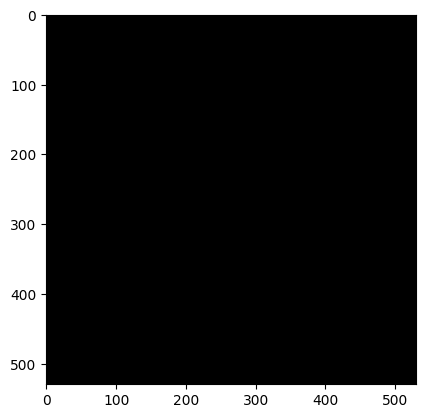

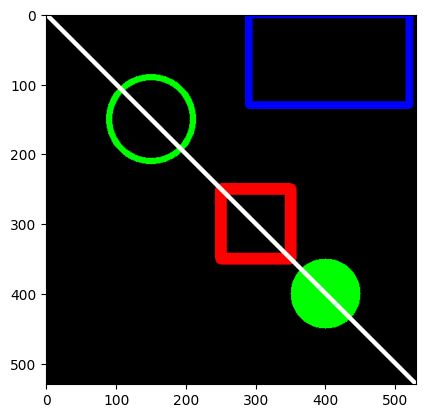

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv

black_img = np.zeros((530, 530, 3), dtype=np.int16)
plt.imshow(black_img)
plt.show()

cv.rectangle(
    black_img,
    pt1=(290, 0),
    pt2=(520, 130),
    color=(0, 0, 255),
    thickness=10
)

cv.rectangle(
    black_img,pt1=(250,250),
    pt2=(350,350),
    color=(255,0,0),
    thickness=15
)

cv.circle(black_img,center=(150,150),
          radius=60,
          color=(0,255,0),
          thickness=8
          )

cv.circle(black_img,center=(400,400),
          radius=50,
          color=(0,255,0),
          thickness=-1)
cv.line(black_img,pt1=(0,0),
        pt2=(530,530),
        color=(255,255,255),thickness=5)
plt.imshow(black_img)
plt.show()

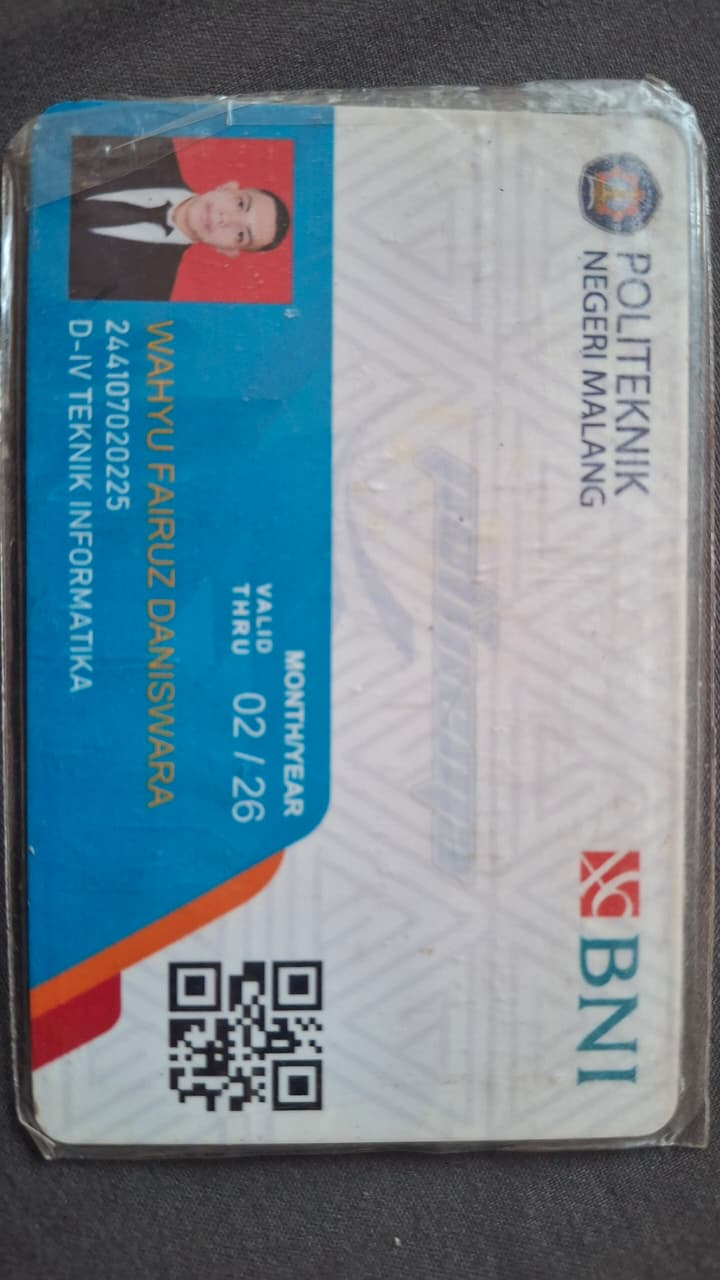

resolusi gambar:  720  x  1280


In [7]:
import cv2 as cv
from google.colab.patches import cv2_imshow
from skimage import io
import matplotlib.pyplot as plt
import numpy as np

img = cv.imread('foto ktm.jpeg')
cv2_imshow(img)

print("resolusi gambar: ", img.shape[1], " x ", img.shape[0])

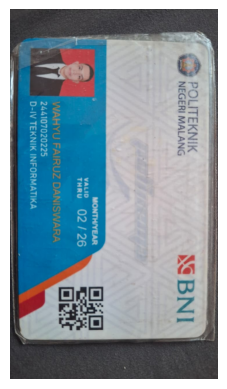

In [10]:
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np

img = cv.imread('foto ktm.jpeg')

img2 = cv.cvtColor(img, cv.COLOR_BGR2RGB)

plt.imshow(img2)
plt.axis('off')
plt.show()

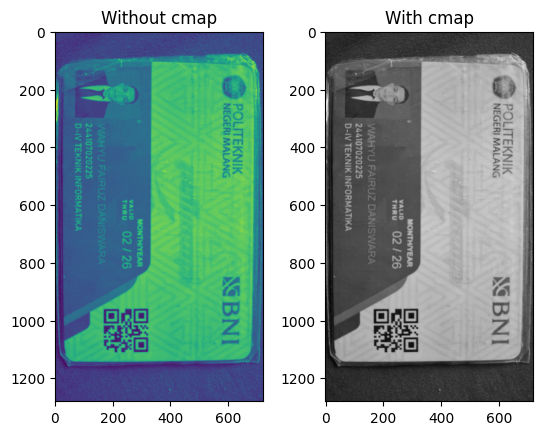

In [12]:
img_gray = cv.imread('foto ktm.jpeg', cv.IMREAD_GRAYSCALE)

# Tanpa cmap
plt.subplot(1, 2, 1)
plt.imshow(img_gray)
plt.title("Without cmap")

# Pakai cmap
plt.subplot(1, 2, 2)
plt.imshow(img_gray, cmap='gray')
plt.title("With cmap")

plt.show()

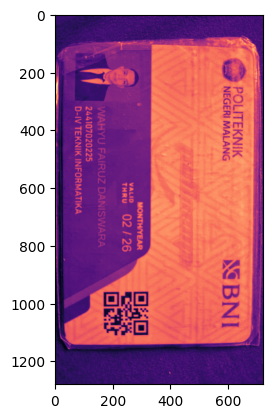

In [13]:
plt.imshow(img_gray, cmap='magma')

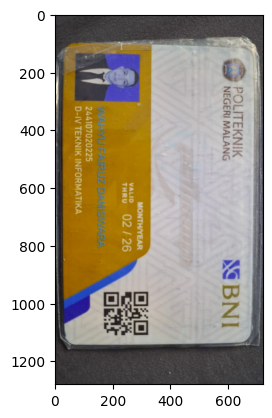

Pixel value: [128 107  69]


In [20]:





plt.imshow(img)
plt.show()

print("Pixel value:", img[100, 100])

In [ ]:
2. The int32 data type has a wider range of values that can be stored compared to int16.

3. It allows the image output to be displayed directly in the notebook by using cv2_imshow from OpenCV.

4. Both methods show the image using the correct RGB color order. However, skimage.io.imread() loads an image in RGB format, whereas cv2.imread() loads it in BGR format.

5. Changing the figsize only changes the displayed size of the image and does not affect the values or dimensions stored in img.shape.

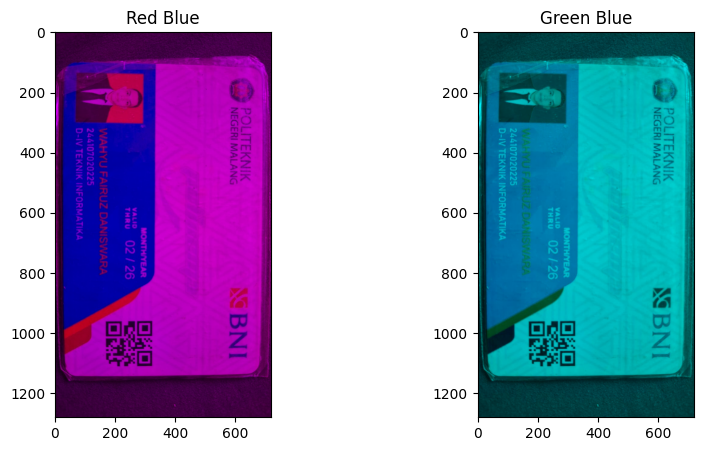

In [21]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread('foto ktm.jpeg')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

img_RB = img_rgb.copy()
img_RB[:, :, 1] = 0

img_GB = img_rgb.copy()
img_GB[:, :, 0] = 0

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(img_RB)
plt.title('Red Blue')

plt.subplot(1, 2, 2)
plt.imshow(img_GB)
plt.title('Green Blue')

plt.show()

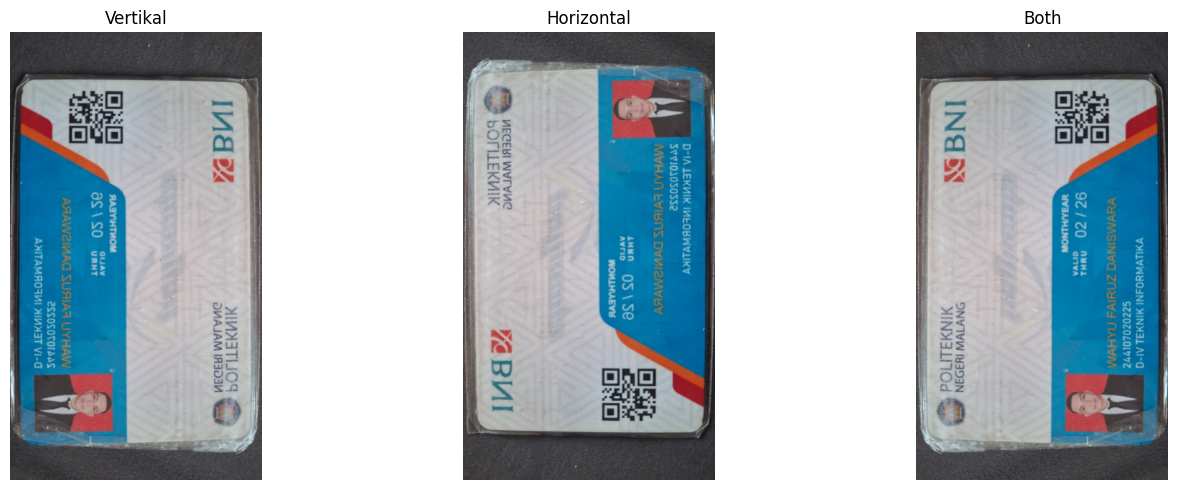

In [22]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread('foto ktm.jpeg')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

img_vertikal = cv2.flip(img_rgb, 0)
img_horizontal = cv2.flip(img_rgb, 1)
img_both = cv2.flip(img_rgb, -1)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(img_vertikal)
axes[0].set_title("Vertikal")
axes[0].axis("off")

axes[1].imshow(img_horizontal)
axes[1].set_title("Horizontal")
axes[1].axis("off")

axes[2].imshow(img_both)
axes[2].set_title("Both")
axes[2].axis("off")

plt.tight_layout()
plt.show()

In [24]:
red_channel = img_rgb[:, :, 0]
avg_red = np.mean(red_channel)

print(f"Average Red Channel Intensity: {avg_red:.2f}")

Average Red Channel Intensity: 112.60


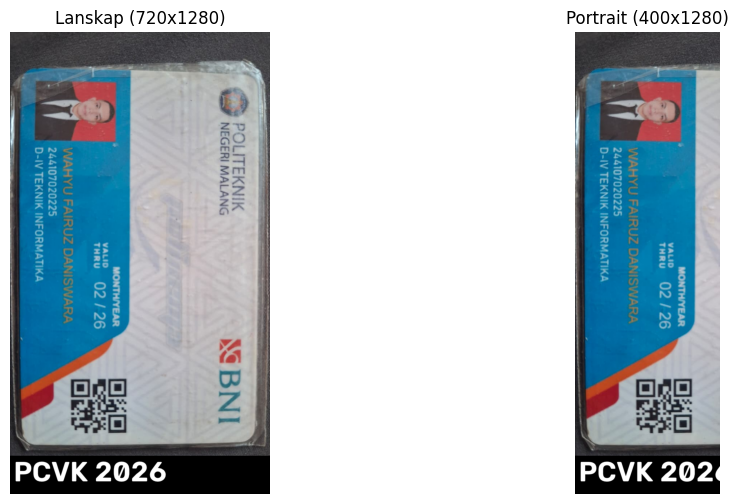

In [26]:
##study casee 1
import cv2
import matplotlib.pyplot as plt

def add_label(img_bgr, teks):
    h, w = img_bgr.shape[:2]
    tinggi_bar = h // 12
    canvas = img_bgr.copy()
    canvas[h - tinggi_bar:h, 0:w] = (0, 0, 0)

    font = cv2.FONT_HERSHEY_SIMPLEX
    font_scale = tinggi_bar / 40
    thickness = max(1, tinggi_bar // 25)
    org = (10, h - tinggi_bar // 3)

    cv2.putText(
        canvas, teks, org, font, font_scale,
        (255, 255, 255), thickness,
        lineType=cv2.LINE_AA
    )

    return canvas


img_landscape = cv2.imread('foto ktm.jpeg')

img_portrait = img_landscape[:, 0:400].copy()

hasil1 = add_label(img_landscape, 'PCVK 2026')
hasil2 = add_label(img_portrait, 'PCVK 2026')

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(hasil1, cv2.COLOR_BGR2RGB))
plt.title(f'Lanskap ({img_landscape.shape[1]}x{img_landscape.shape[0]})')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(hasil2, cv2.COLOR_BGR2RGB))
plt.title(f'Portrait ({img_portrait.shape[1]}x{img_portrait.shape[0]})')
plt.axis('off')

plt.show()

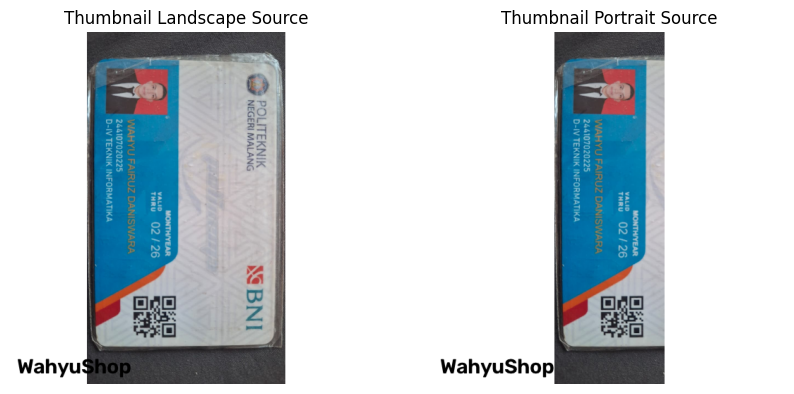

In [30]:
##studycase2

import cv2
import numpy as np
import matplotlib.pyplot as plt

def add_thumbnail_square(
    img_bgr,
    size=500,
    bg_color=(255, 255, 255),
    store_name='WahyuShop'
):
    h, w = img_bgr.shape[:2]

    scale = size / max(h, w)
    w_new = int(w * scale)
    h_new = int(h * scale)

    img_resize = cv2.resize(img_bgr, (w_new, h_new))

    canvas = np.full(
        (size, size, 3),
        bg_color,
        dtype=np.uint8
    )

    x_offset = (size - w_new) // 2
    y_offset = (size - h_new) // 2

    canvas[
        y_offset:y_offset + h_new,
        x_offset:x_offset + w_new
    ] = img_resize

    font = cv2.FONT_HERSHEY_SIMPLEX
    font_scale = size / 500
    thickness = max(1, size // 250)

    cv2.putText(
        canvas,
        store_name,
        (10, size - 15),
        font,
        font_scale,
        (0, 0, 0),
        thickness,
        lineType=cv2.LINE_AA
    )

    return canvas


thumb1 = add_thumbnail_square(img_landscape)
thumb2 = add_thumbnail_square(img_portrait)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(thumb1, cv2.COLOR_BGR2RGB))
plt.title('Thumbnail Landscape Source')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(thumb2, cv2.COLOR_BGR2RGB))
plt.title('Thumbnail Portrait Source')
plt.axis('off')

plt.show()